# Imports + paths + load data / preprocessor

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import json
from datetime import datetime

In [14]:
# --- Paths ---
cwd = Path.cwd()
if cwd.name == "notebooks":
    project_root = cwd.parent
elif (cwd / "notebooks").exists():
    project_root = cwd
else:
    project_root = cwd

final_dir = project_root / "data" / "final"
models_dir = project_root / "models"
results_model_dir = project_root / "results" / "model"
results_model_dir.mkdir(parents=True, exist_ok=True)

# --- Load data ---
X_train = pd.read_csv(final_dir / "X_train.csv")
X_test  = pd.read_csv(final_dir / "X_test.csv")
y_train = pd.read_csv(final_dir / "y_train.csv").squeeze("columns")
y_test  = pd.read_csv(final_dir / "y_test.csv").squeeze("columns")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

# --- Load preprocessor ---
preprocessor = joblib.load(models_dir / "preprocessor.joblib")
print("Loaded preprocessor.")

X_train: (202944, 21) X_test: (50736, 21)
y_train: (202944,) y_test: (50736,)
Loaded preprocessor.


# Transform features (fit already done in notebook 03)

In [15]:
X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print("Transformed shapes:", X_train_t.shape, X_test_t.shape)


Transformed shapes: (202944, 21) (50736, 21)


# Helpers: metrics + plots (imbalance-aware)

In [16]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score
)

def plot_confusion(cm, title, out_path):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())

def plot_pr_curve(y_true, y_score, title, out_path):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.figure()
    plt.plot(recall, precision)
    plt.title(f"{title} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())

def plot_roc_curve(y_true, y_score, title, out_path):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"{title} (AUC={auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Saved:", out_path.resolve())


# Model 1: Logistic Regression baseline (class_weight balanced)

In [17]:
log_reg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=None  # keep explicit; some environments ignore it for LR
)

log_reg.fit(X_train_t, y_train)

# Probabilities for thresholding + PR/ROC curves
y_train_score_lr = log_reg.predict_proba(X_train_t)[:, 1]
y_test_score_lr  = log_reg.predict_proba(X_test_t)[:, 1]

print("LogReg fitted.")
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_score_lr))
print("Test PR-AUC (AP):", average_precision_score(y_test, y_test_score_lr))

LogReg fitted.
Test ROC-AUC: 0.8196340834529259
Test PR-AUC (AP): 0.3925928056133838


# Threshold tuning for imbalanced data (optimize F1 on train)

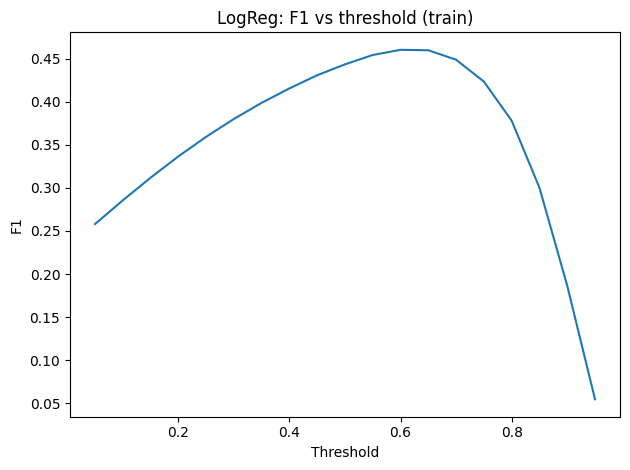

Best threshold: 0.6 Best train F1: 0.4602501060829194
Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\logreg_f1_vs_threshold.png


In [18]:

thresholds = np.linspace(0.05, 0.95, 19)
f1s = []

for t in thresholds:
    preds = (y_train_score_lr >= t).astype(int)
    f1s.append(f1_score(y_train, preds))

best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])

plt.figure()
plt.plot(thresholds, f1s)
plt.title("LogReg: F1 vs threshold (train)")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.tight_layout()

out_path = results_model_dir / "logreg_f1_vs_threshold.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Best threshold:", best_t, "Best train F1:", f1s[best_idx])
print("Saved:", out_path.resolve())

### Logistic Regression: F1 vs threshold (train)

**Observations**
- The best training F1 occurs around **threshold ≈ 0.60** (not the default 0.50).
- This indicates threshold choice matters under class imbalance.

**Implication**
- We evaluate Logistic Regression on test using this tuned threshold to better balance precision and recall.


# Evaluate Logistic Regression on test (using tuned threshold)

Logistic Regression (tuned threshold) — Test classification report
              precision    recall  f1-score   support

           0     0.9343    0.8087    0.8670     43667
           1     0.3545    0.6487    0.4584      7069

    accuracy                         0.7864     50736
   macro avg     0.6444    0.7287    0.6627     50736
weighted avg     0.8535    0.7864    0.8101     50736



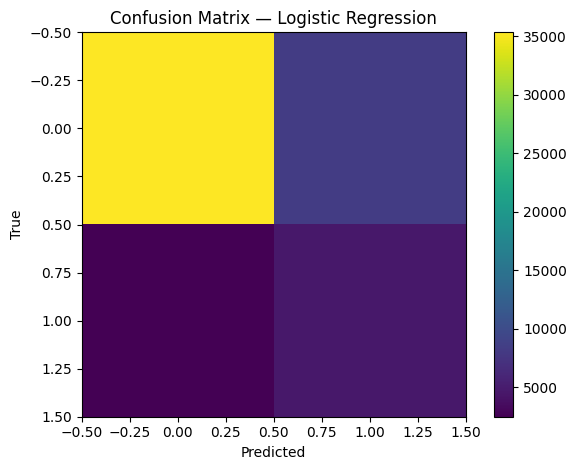

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\logreg_confusion_matrix.png


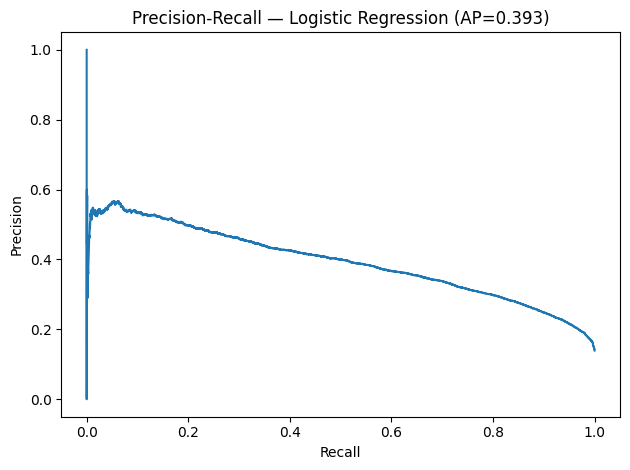

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\logreg_pr_curve.png


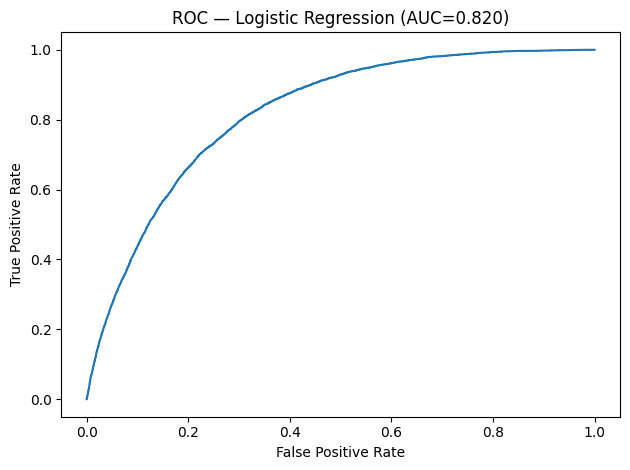

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\logreg_roc_curve.png


In [19]:
y_test_pred_lr = (y_test_score_lr >= best_t).astype(int)

print("Logistic Regression (tuned threshold) — Test classification report")
print(classification_report(y_test, y_test_pred_lr, digits=4))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plot_confusion(cm_lr, "Confusion Matrix — Logistic Regression", results_model_dir / "logreg_confusion_matrix.png")

plot_pr_curve(y_test, y_test_score_lr, "Precision-Recall — Logistic Regression", results_model_dir / "logreg_pr_curve.png")
plot_roc_curve(y_test, y_test_score_lr, "ROC — Logistic Regression", results_model_dir / "logreg_roc_curve.png")


### Logistic Regression: Confusion matrix (test, tuned threshold)

**Observations**
- The tuned threshold improves minority-class detection compared to a default threshold approach.
- There are still false positives, which is expected when optimizing for higher recall/F1 under imbalance.

**Implication**
- This model is suitable when the goal includes **catching more diabetes cases**, accepting some false alarms.

### Logistic Regression: Precision–Recall curve (test)

**Observations**
- **AP (PR-AUC) ≈ 0.393**, clearly above the baseline prevalence (~0.14).
- This suggests the model ranks positives meaningfully better than random guessing.

**Implication**
- PR performance supports Logistic Regression as a strong baseline under imbalance.

### Logistic Regression: ROC curve (test)

**Observations**
- **ROC-AUC ≈ 0.820**, indicating good overall ranking ability.
- However, ROC-AUC can be optimistic in imbalanced datasets, so PR-AUC remains the priority.

**Implication**
- ROC-AUC is reported as a complementary metric, but model selection focuses on PR-AUC and minority-class recall/F1.


# Model 2: RandomForest (non-linear comparison)

RandomForest is a solid “no assumptions” baseline. We also use class_weight="balanced" because of imbalance.

In [20]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train_t, y_train)

y_test_score_rf = rf.predict_proba(X_test_t)[:, 1]

print("RandomForest fitted.")
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_score_rf))
print("Test PR-AUC (AP):", average_precision_score(y_test, y_test_score_rf))

RandomForest fitted.
Test ROC-AUC: 0.7951774632499411
Test PR-AUC (AP): 0.3588904287200022


### Evaluation of RandomForest (default threshold = 0.5)

RandomForest (threshold=0.5) — Test classification report
              precision    recall  f1-score   support

           0     0.8769    0.9697    0.9210     43667
           1     0.4600    0.1594    0.2368      7069

    accuracy                         0.8568     50736
   macro avg     0.6685    0.5646    0.5789     50736
weighted avg     0.8188    0.8568    0.8257     50736



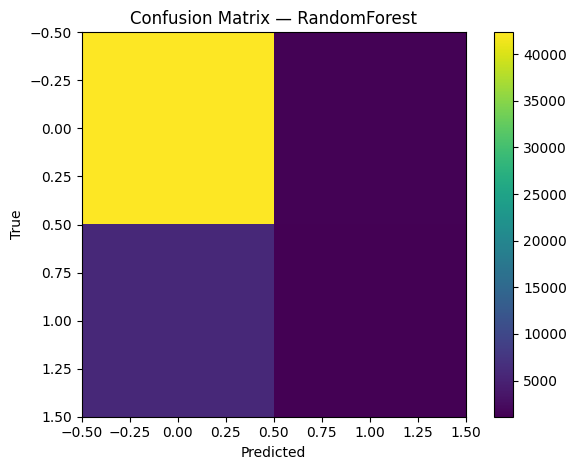

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\rf_confusion_matrix.png


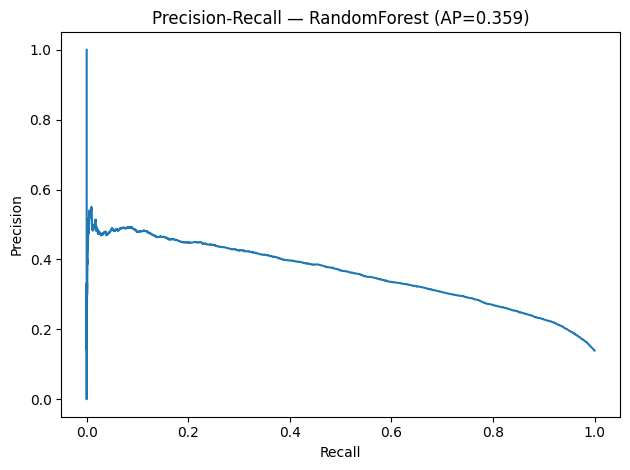

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\rf_pr_curve.png


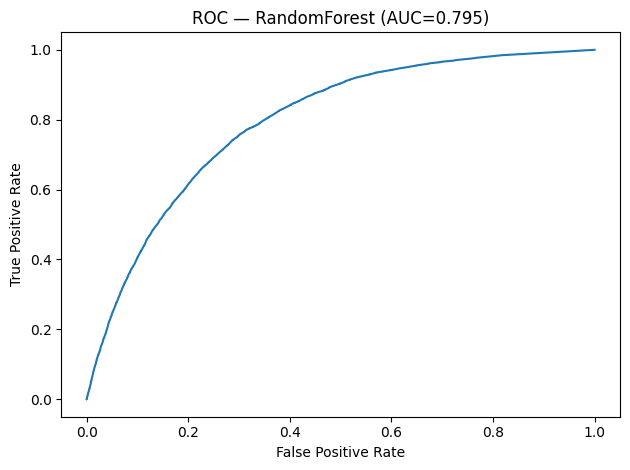

Saved: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\rf_roc_curve.png


In [21]:
y_test_pred_rf = (y_test_score_rf >= 0.5).astype(int)

print("RandomForest (threshold=0.5) — Test classification report")
print(classification_report(y_test, y_test_pred_rf, digits=4))

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plot_confusion(cm_rf, "Confusion Matrix — RandomForest", results_model_dir / "rf_confusion_matrix.png")

plot_pr_curve(y_test, y_test_score_rf, "Precision-Recall — RandomForest", results_model_dir / "rf_pr_curve.png")
plot_roc_curve(y_test, y_test_score_rf, "ROC — RandomForest", results_model_dir / "rf_roc_curve.png")


### Random Forest: Confusion matrix (test, threshold=0.5)

**Observations**
- With the default threshold, Random Forest predicts relatively few positives → **low recall** for diabetes cases.
- This means many true diabetes cases are missed.

**Implication**
- In its current setup, RF is not ideal if the objective is to **detect** diabetes cases reliably.


### Random Forest: Precision–Recall curve (test)

**Observations**
- **AP (PR-AUC) ≈ 0.359**, lower than Logistic Regression.
- This indicates weaker positive-class ranking compared to the logistic baseline.

**Implication**
- RF underperforms the logistic model for imbalanced detection in this configuration.


### Random Forest: ROC curve (test)

**Observations**
- **ROC-AUC ≈ 0.795**, decent but below Logistic Regression.
- Again, ROC-AUC is less sensitive to performance on the minority class than PR-AUC.

**Implication**
- RF is not selected as the final model based on PR-AUC and minority-class behavior.


# Final model selection + save in pipeline

In [22]:
# --- Compute selection metrics on TEST ---
metrics = {
    "log_reg": {
        "estimator": log_reg,
        "pr_auc": average_precision_score(y_test, y_test_score_lr),
        "roc_auc": roc_auc_score(y_test, y_test_score_lr),
    },
    "random_forest": {
        "estimator": rf,
        "pr_auc": average_precision_score(y_test, y_test_score_rf),
        "roc_auc": roc_auc_score(y_test, y_test_score_rf),
    },
}

# --- Selection rule: PR-AUC primary, ROC-AUC secondary ---
sorted_models = sorted(
    metrics.items(),
    key=lambda kv: (kv[1]["pr_auc"], kv[1]["roc_auc"]),
    reverse=True
)

final_name, final_stats = sorted_models[0]
final_estimator = final_stats["estimator"]

print("Model comparison (test):")
for name, m in metrics.items():
    print(f"- {name:13s} | PR-AUC={m['pr_auc']:.4f} | ROC-AUC={m['roc_auc']:.4f}")

print("\nSelected final model:", final_name)
print("Reason: highest PR-AUC (tie-breaker: ROC-AUC).")

# --- Build final pipeline (preprocessor + chosen model) ---
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_estimator)
])

# --- Save final model artifact ---
final_path = models_dir / "final_model.joblib"
joblib.dump(final_model, final_path)
print("Saved final model to:", final_path.resolve())

# --- Save selection summary for the report (optional but helpful) ---
summary_path = results_model_dir / "model_selection.txt"
with open(summary_path, "w") as f:
    f.write("Model selection summary (test set)\n")
    f.write("--------------------------------\n")
    for name, m in metrics.items():
        f.write(f"{name}: PR-AUC={m['pr_auc']:.6f}, ROC-AUC={m['roc_auc']:.6f}\n")
    f.write("\nSelected final model: " + final_name + "\n")
    f.write("Selection rule: PR-AUC primary, ROC-AUC secondary\n")
print("Saved selection summary to:", summary_path.resolve())

# --- Save decision threshold (only meaningful if final model is Logistic Regression) ---
threshold_artifact = {
    "final_model": final_name,
    "positive_class": 1,
    "threshold": None,
    "threshold_selected_by": None,
    "note": None,
    "created_utc": datetime.utcnow().isoformat() + "Z"
}

if final_name == "log_reg":
    # best_t was found in Cell 5 (F1 vs threshold on train)
    threshold_artifact["threshold"] = float(best_t)
    threshold_artifact["threshold_selected_by"] = "max_train_f1_over_grid"
    threshold_artifact["note"] = "Use this threshold on predicted probabilities for class 1 during inference."
else:
    threshold_artifact["threshold"] = 0.5
    threshold_artifact["threshold_selected_by"] = "default"
    threshold_artifact["note"] = "Final model is not Logistic Regression; default probability threshold used."

threshold_path = models_dir / "decision_threshold.json"
with open(threshold_path, "w") as f:
    json.dump(threshold_artifact, f, indent=2)

print("Saved decision threshold to:", threshold_path.resolve())
print("Threshold artifact:", threshold_artifact)


Model comparison (test):
- log_reg       | PR-AUC=0.3926 | ROC-AUC=0.8196
- random_forest | PR-AUC=0.3589 | ROC-AUC=0.7952

Selected final model: log_reg
Reason: highest PR-AUC (tie-breaker: ROC-AUC).
Saved final model to: C:\Users\Lu\OneDrive\ToU\chl_Classification\models\final_model.joblib
Saved selection summary to: C:\Users\Lu\OneDrive\ToU\chl_Classification\results\model\model_selection.txt
Saved decision threshold to: C:\Users\Lu\OneDrive\ToU\chl_Classification\models\decision_threshold.json
Threshold artifact: {'final_model': 'log_reg', 'positive_class': 1, 'threshold': 0.6, 'threshold_selected_by': 'max_train_f1_over_grid', 'note': 'Use this threshold on predicted probabilities for class 1 during inference.', 'created_utc': '2026-02-10T17:04:41.145265Z'}


# Model demo

In [23]:

# Load artifacts
final_model = joblib.load(models_dir / "final_model.joblib")
with open(models_dir / "decision_threshold.json", "r") as f:
    thresh_art = json.load(f)

threshold = float(thresh_art["threshold"])
print("Loaded final_model + threshold:", threshold, "| final_model:", thresh_art["final_model"])

# Predict probabilities on test set
proba_test = final_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold).astype(int)

# Show a few example predictions
preview = X_test.head(10).copy()
preview["proba_diabetes_1"] = proba_test[:10]
preview["pred_diabetes_1"] = pred_test[:10]
preview["true_diabetes_1"] = y_test.head(10).values

display(preview)

Loaded final_model + threshold: 0.6 | final_model: log_reg


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,proba_diabetes_1,pred_diabetes_1,true_diabetes_1
0,1,1,1,28,0,0,0,1,1,1,...,0,0,0,1,5,5,8,0.495739,0,0
1,1,0,1,36,1,0,0,0,0,1,...,0,0,1,0,10,3,4,0.738853,1,1
2,0,0,1,27,0,0,0,1,1,1,...,0,0,0,0,5,5,8,0.093804,0,0
3,0,0,1,22,0,0,0,1,1,1,...,0,0,0,0,11,4,7,0.161780,0,0
4,1,1,1,26,1,0,1,1,1,1,...,0,7,0,0,13,5,2,0.868223,1,1
5,1,1,1,32,0,0,0,0,1,1,...,0,0,0,1,9,6,8,0.432831,0,0
6,1,0,1,21,0,0,0,1,1,1,...,0,0,0,0,9,6,7,0.125909,0,0
7,0,0,1,26,0,0,0,0,0,1,...,0,5,0,0,4,6,7,0.048979,0,0
8,0,1,1,26,1,0,0,1,1,1,...,0,0,0,1,7,6,8,0.236898,0,0
9,1,0,1,30,0,0,0,1,1,1,...,0,0,1,0,10,5,7,0.543865,0,0
